# An Explainable Intelligent Diabetes Risk Prediction and Recommendation System using Machine Learning

## Project Objective

The objective of this project is to develop an intelligent diabetes prediction system using machine learning and explainable AI techniques. The system aims to predict diabetes risk accurately, analyze important health factors, and provide personalized recommendations for users.


## Dataset Description

The dataset used in this project is the Diabetes Prediction Dataset obtained from Kaggle. It contains medical and lifestyle-related attributes such as age, BMI, HbA1c level, blood glucose level, hypertension, heart disease, and smoking history.

**STEP 1: Install Libraries**

In [1]:
!pip install xgboost imbalanced-learn shap

**STEP 2: Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import ADASYN

**STEP 3: Upload Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


**STEP 4: Load Dataset**

In [4]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**STEP 5: Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


**STEP 6: Missing Value Check**

In [28]:
df.isnull().sum()

,0
age,0
hypertension,0
heart_disease,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0
gender_Male,0
gender_Other,0
smoking_history_current,0


**STEP 7: Preprocessing**

In [7]:
df = pd.get_dummies(df, drop_first=True)

**STEP 8: Define Features and Target**

In [8]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

**STEP 9: Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**STEP 10: Class Distribution Visualization**

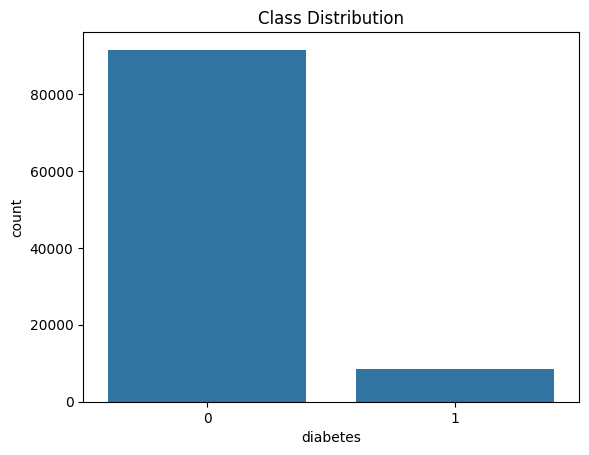

In [24]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

**STEP 11: Handle Class Imbalance (ADASYN)**

In [10]:
adasyn = ADASYN(random_state=42)

X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

**STEP 12: Train Models**

**Logistic Regression**

In [11]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

**Random Forest**

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

**XGBoost (MAIN MODEL)**

In [13]:
xgb = XGBClassifier(random_state=42)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

**STEP 13: Compare Models**

In [31]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

    results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df

Logistic Regression: 0.8724
Random Forest: 0.9569
XGBoost: 0.9631


,Model,Accuracy
0,Logistic Regression,0.87245
1,Random Forest,0.95695
2,XGBoost,0.96310


**STEP 14: Model Comparison Graph**

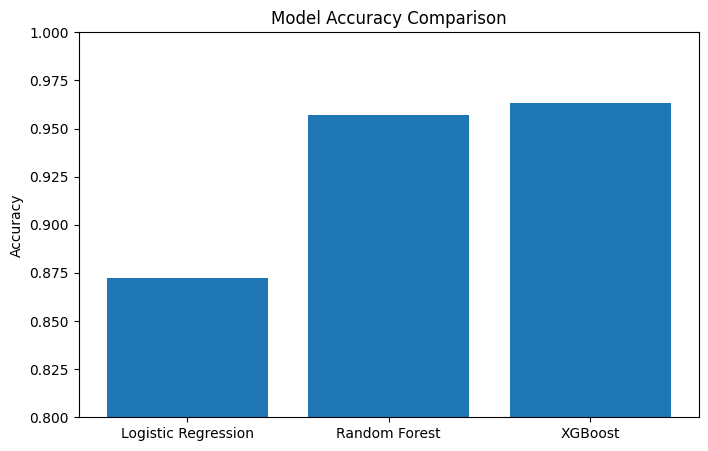

In [26]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.ylim(0.8,1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

**STEP 15: Classification Report**

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18292
           1       0.81      0.74      0.77      1708

    accuracy                           0.96     20000
   macro avg       0.89      0.86      0.88     20000
weighted avg       0.96      0.96      0.96     20000



**STEP 16: Confusion Matrix (XGBoost)**

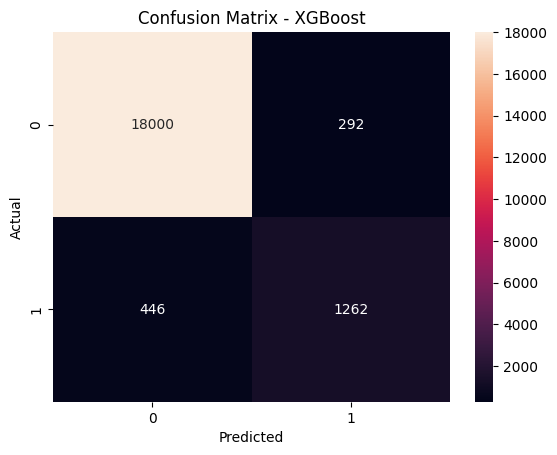

In [16]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**STEP 17: ROC Curve**

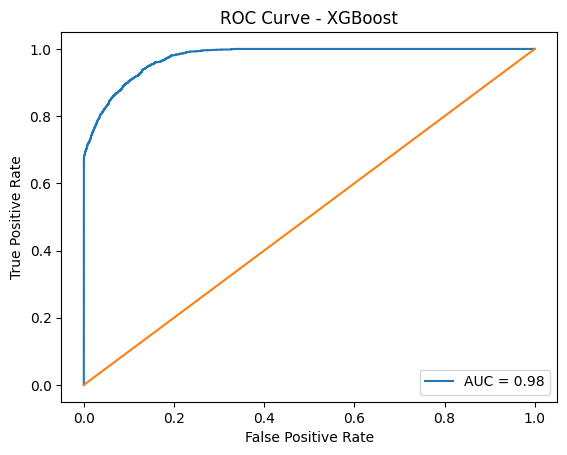

In [17]:
y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1])

plt.title("ROC Curve - XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

**STEP 18: Explainable AI (SHAP)**

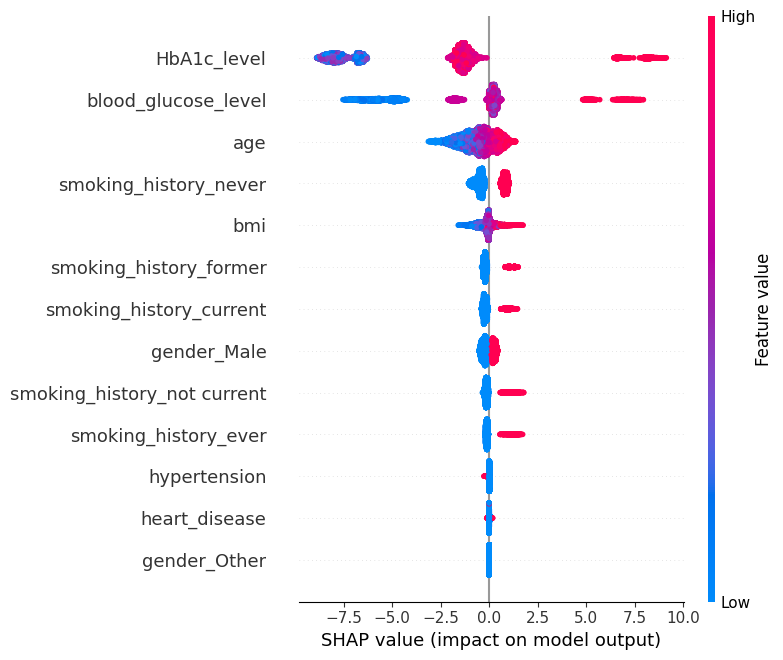

In [19]:
import shap

explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

**STEP 19: Feature Importance Plot**

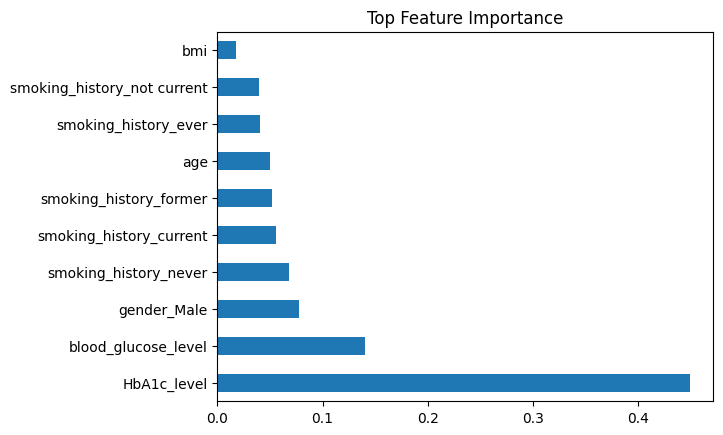

In [27]:
import pandas as pd

feature_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top Feature Importance")
plt.show()

**STEP 20: Risk Level Prediction (NEW FEATURE)**

In [20]:
sample = X_test.iloc[0]

prob = best_xgb.predict_proba([sample])[0][1]

if prob < 0.3:
    risk = "Low Risk"

elif prob < 0.7:
    risk = "Medium Risk"

else:
    risk = "High Risk"

print("Risk Level:", risk)

Risk Level: Low Risk


**STEP 21: Personalized Recommendation System (NEW FEATURE)**

In [29]:
def diabetes_recommendation(row):

    recommendations = []

    # HbA1c Level
    if row['HbA1c_level'] > 6.5:
        recommendations.append(
            "High HbA1c detected - monitor blood sugar levels regularly."
        )

    # Blood Glucose
    if row['blood_glucose_level'] > 140:
        recommendations.append(
            "Blood glucose level is high - reduce sugar intake and follow a balanced diet."
        )

    # BMI
    if row['bmi'] > 30:
        recommendations.append(
            "BMI indicates obesity - maintain regular exercise and healthy eating habits."
        )

    # Hypertension
    if row['hypertension'] == 1:
        recommendations.append(
            "High blood pressure detected - reduce salt intake and monitor BP regularly."
        )

    # Heart Disease
    if row['heart_disease'] == 1:
        recommendations.append(
            "Heart disease history detected - maintain regular cardiovascular checkups."
        )

    # Smoking History
    smoking_cols = [
        col for col in row.index
        if "smoking_history" in col
    ]

    smoking_flag = any(row[col] == 1 for col in smoking_cols)

    if smoking_flag:
        recommendations.append(
            "Smoking-related history detected - avoid smoking and maintain healthy lifestyle habits."
        )

    # If no major risk
    if len(recommendations) == 0:
        recommendations.append(
            "Health parameters appear normal. Maintain a healthy lifestyle and regular checkups."
        )

    return recommendations

**STEP 22: Generate Recommendation**

In [30]:
prediction = best_xgb.predict([sample])

print(
    "Prediction:",
    "Diabetic" if prediction[0]==1 else "Non-Diabetic"
)

print("\nRecommendations:")

for rec in diabetes_recommendation(sample):
    print("-", rec)

Prediction: Non-Diabetic

Recommendations:
- Health parameters appear normal. Maintain a healthy lifestyle and regular checkups.


**STEP 22: Saving the Model**

In [32]:
import pickle

pickle.dump(best_xgb, open("diabetes_model.pkl", "wb"))

**STEP 23: Download the Model**

In [33]:
from google.colab import files
files.download("diabetes_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- This project presented an intelligent and explainable diabetes prediction system using machine learning techniques. Multiple machine learning models, including Logistic Regression, Random Forest, and XGBoost, were implemented and evaluated on the Diabetes Prediction Dataset. Among all the models, XGBoost achieved the highest accuracy of approximately 96.31%, making it the most effective model for diabetes prediction in this study.

- To improve the reliability and quality of prediction, data preprocessing and class imbalance handling using ADASYN were performed. Different evaluation techniques such as confusion matrix, ROC curve, and model comparison graphs were used to validate the performance of the models.

- In addition to prediction, Explainable AI using SHAP was implemented to identify and interpret the most influential features affecting diabetes risk. This increased the transparency and interpretability of the system.

- A major contribution of this project is the inclusion of a diabetes risk-level analysis and personalized recommendation system, which makes the model more practical and user-oriented instead of providing only a binary prediction. The system can help users better understand their health condition and encourage preventive healthcare measures.

- Overall, the project demonstrates that integrating machine learning, explainable AI, and recommendation-based analysis can create a reliable and intelligent diabetes risk prediction system suitable for real-world healthcare applications.

## Future Scope

- Integration with real-time healthcare systems
- Development of mobile/web application
- Integration with IoT health devices
- Deployment using Streamlit
- Use of deep learning models for further improvement